# Part C: PPO Training
Train and evaluate a single-agent PPO controller on the operational hospital-flow environment.


## Install Requirements
This installs from `requirements.txt` when available, otherwise it installs the minimum PPO dependencies.


In [1]:
import os
import sys
import subprocess

def install_requirements():
    if os.path.exists("requirements.txt"):
        print("Installing dependencies from requirements.txt...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-r", "requirements.txt"
        ])
    else:
        print("requirements.txt not found. Installing minimum required packages...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install",
            "stable-baselines3",
            "gymnasium",
            "numpy",
            "pandas",
            "matplotlib",
            "torch"
        ])

install_requirements()


Installing dependencies from requirements.txt...


## Imports
These imports cover PPO, environment checking, monitoring, evaluation, tables, plots, and tensors.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy


c:\Users\ybenj\anaconda3\envs\machine-learning\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.2 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
c:\Users\ybenj\anaconda3\envs\machine-learning\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.2 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
c:\Users\ybenj\anaconda3\envs\machine-learning\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.2 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
c:\Users\ybenj\anaconda3\envs\machine-learning\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.2 when it was built against 1.14.5, this may cause problems


## CUDA / Device Check
CUDA is used when available; otherwise PPO training falls back to CPU without crashing.


In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Selected device: {DEVICE}")

if DEVICE == "cuda":
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA not available. Training will run on CPU.")


Selected device: cuda
GPU name: NVIDIA GeForce RTX 3060 Laptop GPU


## Environment Loading or Definition
`HospitalPPOEnv` is copied into this notebook so training can run independently without editing previous notebooks.


## Environment Support Imports
These support the copied `HospitalPPOEnv` class and Gymnasium compatibility.


In [4]:
from __future__ import annotations

from collections import deque
from dataclasses import dataclass
from typing import Any, Deque, Dict, List, Optional, Tuple

import gymnasium as gym
from gymnasium import spaces


## Staff Schedule
The schedule abstracts staff capacity by shift, without modelling staff movement.


In [5]:
STAFF_SCHEDULE = {
    "day": {
        "nurses": 6,
        "doctors": 5,
        "physicians": 3,
        "radiologists": 2,
        "receptionists": 3,
        "administrators": 2,
        "paramedics": 4,
    },
    "evening": {
        "nurses": 4,
        "doctors": 3,
        "physicians": 2,
        "radiologists": 1,
        "receptionists": 2,
        "administrators": 1,
        "paramedics": 3,
    },
    "night": {
        "nurses": 2,
        "doctors": 1,
        "physicians": 1,
        "radiologists": 1,
        "receptionists": 1,
        "administrators": 1,
        "paramedics": 2,
    },
}


## Patient and Action Constants
Constants define patient types, stages, action meanings, shift encoding, and arrival probabilities.


In [6]:
PATIENT_TYPES = {
    0: "emergency",
    1: "urgent",
    2: "elective_minor",
}

PATIENT_STAGES = {
    0: "arrival",
    1: "registration",
    2: "assessment",
    3: "triage",
    4: "imaging_tests",
    5: "treatment",
    6: "resus",
    7: "major",
    8: "minor",
    9: "general_admission",
    10: "icu_admission",
    11: "discharge",
    12: "delay_wait",
}

ACTION_MEANINGS = {
    0: "do_nothing",
    1: "register_patient",
    2: "move_to_assessment",
    3: "send_to_minor",
    4: "send_to_major",
    5: "send_to_resus",
    6: "request_imaging",
    7: "process_imaging",
    8: "treat_patient",
    9: "admit_general",
    10: "admit_icu",
    11: "discharge_patient",
    12: "delay_patient",
    13: "preserve_icu_capacity",
    14: "prioritise_emergency_flow",
}

SHIFT_ENCODING = {
    "day": 0,
    "evening": 1,
    "night": 2,
}

PATIENT_TYPE_PROBABILITIES = np.asarray([0.2, 0.3, 0.5], dtype=np.float64)


## Patient Record
Patients are lightweight operational records for queue and stage tracking.


In [7]:
@dataclass(eq=False)
class Patient:
    patient_type: int
    stage: int = 0
    waiting_time: int = 0
    needs_imaging: bool = False
    area: Optional[str] = None


## Environment Class Shell
The existing environment logic is copied here; subclassing `gym.Env` is the Stable-Baselines3 compatibility fix.


In [8]:
class HospitalPPOEnv(gym.Env):
    """Single-agent operational hospital-flow environment for later PPO training.
    
    This is not a grid-world. It models queues, stages, staff capacity, beds,
    admissions, discharges, waiting time, and congestion.
    """

    metadata = {"name": "HospitalPPOEnv"}


## Environment Initialisation
Initialises capacities, probabilities, action/observation spaces, RNG, and queues.


In [9]:
# Functionality: constructor, configurable capacities, action space, observation space, and queues.
# Metrics: max capacities, arrival_probability, and discharge probabilities are set here.

def __init__(
        self,
        registration_queue_max: int = 20,
        assessment_queue_max: int = 20,
        resus_max: int = 3,
        major_max: int = 8,
        minor_max: int = 10,
        general_max: int = 20,
        icu_max: int = 6,
        max_steps: int = 500,
        arrival_probability: float = 0.65,
        patient_type_probabilities: np.ndarray = PATIENT_TYPE_PROBABILITIES,
        staff_schedule: Optional[Dict[str, Dict[str, int]]] = None,
    ) -> None:
        gym.Env.__init__(self)
        self.registration_queue_max = int(registration_queue_max)
        self.assessment_queue_max = int(assessment_queue_max)
        self.resus_max = int(resus_max)
        self.major_max = int(major_max)
        self.minor_max = int(minor_max)
        self.general_max = int(general_max)
        self.icu_max = int(icu_max)
        self.max_steps = int(max_steps)
        self.arrival_probability = float(arrival_probability)
        self.patient_type_probabilities = np.asarray(patient_type_probabilities, dtype=np.float64)
        self.patient_type_probabilities /= self.patient_type_probabilities.sum()
        self.staff_schedule = staff_schedule or STAFF_SCHEDULE

        self.resus_release_probability = 0.25
        self.major_release_probability = 0.30
        self.minor_release_probability = 0.50
        self.general_discharge_probability = 0.35
        self.icu_discharge_probability = 0.20

        self.action_space = spaces.Discrete(15)
        self.observation_space = spaces.Box(
            low=np.zeros(18, dtype=np.float32),
            high=np.asarray(
                [
                    self.registration_queue_max,
                    self.assessment_queue_max,
                    self.resus_max,
                    self.major_max,
                    self.minor_max,
                    self.general_max,
                    self.icu_max,
                    2,
                    12,
                    self.max_steps,
                    max(v["nurses"] for v in self.staff_schedule.values()),
                    max(v["doctors"] for v in self.staff_schedule.values()),
                    max(v["physicians"] for v in self.staff_schedule.values()),
                    max(v["radiologists"] for v in self.staff_schedule.values()),
                    max(v["receptionists"] for v in self.staff_schedule.values()),
                    max(v["administrators"] for v in self.staff_schedule.values()),
                    max(v["paramedics"] for v in self.staff_schedule.values()),
                    2,
                ],
                dtype=np.float32,
            ),
            dtype=np.float32,
        )

        self._np_random = np.random.default_rng()
        self._arrival_queue: Deque[Patient] = deque()
        self._registration_patients: Deque[Patient] = deque()
        self._assessment_patients: Deque[Patient] = deque()
        self._imaging_patients: Deque[Patient] = deque()
        self._treatment_patients: Deque[Patient] = deque()
        self._admission_patients: Deque[Patient] = deque()
        self._resus_patients: Deque[Patient] = deque()
        self._major_patients: Deque[Patient] = deque()
        self._minor_patients: Deque[Patient] = deque()
        self._general_patients: Deque[Patient] = deque()
        self._icu_patients: Deque[Patient] = deque()

        self._reset_public_state()



HospitalPPOEnv.__init__ = __init__


## Reset and Step API
Implements the Gymnasium return format used by Stable-Baselines3 PPO.


In [10]:
# Functionality: Gymnasium-style reset and step.
# Metrics: reward, terminated, truncated, and info are returned for PPO rollouts.

def reset(self, seed: Optional[int] = None, options: Optional[Dict[str, Any]] = None) -> Tuple[np.ndarray, Dict[str, Any]]:
        if seed is not None:
            self._np_random = np.random.default_rng(seed)

        options = options or {}
        self.timestep = 0
        self._preserve_icu_mode = False

        for queue in self._all_queues():
            queue.clear()

        self.resus_free = self.resus_max
        self.major_free = self.major_max
        self.minor_free = self.minor_max
        self.general_free = self.general_max
        self.icu_free = self.icu_max
        self.shift = self._shift_from_timestep(self.timestep)
        self._apply_shift_staffing()

        initial_patients = int(options.get("initial_patients", 1))
        for _ in range(max(initial_patients, 0)):
            self._arrival_queue.append(self._new_patient())

        self._sync_public_state()
        return self._get_observation(), self._get_info(events=["reset"])

def step(self, action: int) -> Tuple[np.ndarray, float, bool, bool, Dict[str, Any]]:
        action = int(np.clip(action, 0, self.action_space.n - 1))
        self.timestep += 1
        self.shift = self._shift_from_timestep(self.timestep)
        self._apply_shift_staffing()

        reward_components = []
        events = []

        release_reward = self._release_capacity(events)
        reward_components.append(("release_throughput", release_reward))

        if self._np_random.random() < self.arrival_probability:
            self._arrival_queue.append(self._new_patient())
            events.append("new_patient_arrived")

        action_reward = self._apply_action(action, events)
        reward_components.append(("action_reward", action_reward))

        waiting_penalty = self._update_waiting_times()
        reward_components.append(("waiting_penalty", -waiting_penalty))

        congestion_penalty = self._queue_congestion_penalty()
        reward_components.append(("queue_congestion_penalty", -congestion_penalty))

        icu_reward = self._icu_preservation_reward()
        reward_components.append(("icu_preservation_reward", icu_reward))

        self._sync_public_state()
        reward = float(sum(value for _, value in reward_components))
        terminated = False
        truncated = self.timestep >= self.max_steps
        info = self._get_info(
            action=action,
            action_meaning=ACTION_MEANINGS[action],
            events=events,
            reward_components=dict(reward_components),
        )
        return self._get_observation(), reward, terminated, truncated, info



HospitalPPOEnv.reset = reset

HospitalPPOEnv.step = step


## Action Dispatch
Maps one discrete PPO action to the correct hospital-flow operation.


In [11]:
# Functionality: maps one PPO action to one hospital-flow operation.
# Metrics: the selected action controls delta_queue, delta_capacity, and patient stage changes.

def _apply_action(self, action: int, events: List[str]) -> float:
        if action == 0:
            events.append("do_nothing")
            return -0.1 if self._has_waiting_patients() else 0.0
        if action == 1:
            return self._register_patient(events)
        if action == 2:
            return self._move_to_assessment(events)
        if action == 3:
            return self._send_to_area("minor", events)
        if action == 4:
            return self._send_to_area("major", events)
        if action == 5:
            return self._send_to_area("resus", events)
        if action == 6:
            return self._request_imaging(events)
        if action == 7:
            return self._process_imaging(events)
        if action == 8:
            return self._treat_patient(events)
        if action == 9:
            return self._admit_general(events)
        if action == 10:
            return self._admit_icu(events)
        if action == 11:
            return self._discharge_patient(events)
        if action == 12:
            return self._delay_patient(events)
        if action == 13:
            return self._preserve_icu_capacity(events)
        if action == 14:
            return self._prioritise_emergency_flow(events)
        return 0.0



HospitalPPOEnv._apply_action = _apply_action


## Registration and Assessment
Handles front-door movement from arrival to registration and assessment.


In [12]:
# Functionality: patient registration and movement into assessment.
# Metrics: changes registration_queue and assessment_queue.

def _register_patient(self, events: List[str]) -> float:
        if not self._arrival_queue or len(self._registration_patients) >= self.registration_queue_max:
            events.append("registration_blocked")
            return -1.0
        if self.receptionists_available <= 0:
            events.append("no_receptionist_available")
            return -1.0
        patient = self._pop_priority(self._arrival_queue)
        patient.stage = 1
        self._registration_patients.append(patient)
        events.append("patient_registered")
        return 1.0 if patient.patient_type != 0 else 2.0

def _move_to_assessment(self, events: List[str]) -> float:
        if not self._registration_patients or len(self._assessment_patients) >= self.assessment_queue_max:
            events.append("assessment_move_blocked")
            return -1.0
        patient = self._pop_priority(self._registration_patients)
        patient.stage = 2
        self._assessment_patients.append(patient)
        events.append("patient_moved_to_assessment")
        return 1.0 if patient.patient_type != 0 else 2.0



HospitalPPOEnv._register_patient = _register_patient

HospitalPPOEnv._move_to_assessment = _move_to_assessment


## Triage Routing
Routes assessed patients to minor, major, or resus and rewards clinically appropriate routing.


In [13]:
# Functionality: routes assessed patients to minor, major, or resus.
# Metrics: rewards emergency-to-resus, urgent-to-major, minor-to-minor, and penalises unsafe routing.

def _send_to_area(self, area: str, events: List[str]) -> float:
        if not self._assessment_patients:
            events.append(f"send_to_{area}_blocked_no_patient")
            return -1.0
        if self.nurses_available <= 0:
            events.append("no_nurse_available")
            return -1.0
        if getattr(self, f"{area}_free") <= 0:
            events.append(f"send_to_{area}_blocked_no_capacity")
            patient = self._peek_priority(self._assessment_patients)
            if patient and patient.patient_type == 0 and area in {"resus", "major"}:
                return -8.0
            return -2.0

        patient = self._pop_priority(self._assessment_patients)
        patient.stage = {"resus": 6, "major": 7, "minor": 8}[area]
        patient.area = area
        getattr(self, f"_{area}_patients").append(patient)
        self._treatment_patients.append(patient)
        setattr(self, f"{area}_free", getattr(self, f"{area}_free") - 1)
        events.append(f"patient_sent_to_{area}")

        if patient.patient_type == 0 and area == "resus":
            return 10.0
        if patient.patient_type == 1 and area == "major":
            return 6.0
        if patient.patient_type == 2 and area == "minor":
            return 3.0
        if patient.patient_type != 0 and area == "resus":
            return -5.0
        if patient.patient_type == 0 and area == "minor":
            return -8.0
        return 0.5



HospitalPPOEnv._send_to_area = _send_to_area


## Imaging and Treatment
Handles imaging requests, imaging completion, treatment, and readiness for admission.


In [14]:
# Functionality: imaging request, imaging processing, and treatment progression.
# Metrics: changes patient_stage, imaging queue, treatment queue, and admission readiness.

def _request_imaging(self, events: List[str]) -> float:
        patient = self._pop_priority(self._treatment_patients)
        if patient is None:
            events.append("imaging_request_blocked")
            return -1.0
        patient.stage = 4
        patient.needs_imaging = True
        self._imaging_patients.append(patient)
        events.append("imaging_requested")
        return 1.0 if patient.patient_type in {0, 1} else 0.5

def _process_imaging(self, events: List[str]) -> float:
        if not self._imaging_patients:
            events.append("process_imaging_blocked")
            return -1.0
        if self.radiologists_available <= 0:
            events.append("no_radiologist_available")
            return -1.0
        patient = self._pop_priority(self._imaging_patients)
        patient.needs_imaging = False
        patient.stage = 5
        self._treatment_patients.append(patient)
        events.append("imaging_processed")
        return 1.5

def _treat_patient(self, events: List[str]) -> float:
        patient = self._pop_priority(self._treatment_patients)
        if patient is None:
            events.append("treatment_blocked")
            return -1.0
        if self.doctors_available <= 0:
            self._treatment_patients.appendleft(patient)
            events.append("no_doctor_available")
            return -1.0
        patient.stage = 5
        events.append("patient_treated")
        if patient.patient_type == 2:
            patient.stage = 11
            self._release_area(patient)
            events.append("minor_patient_ready_for_discharge")
            return 3.0
        self._admission_patients.append(patient)
        return 2.0



HospitalPPOEnv._request_imaging = _request_imaging

HospitalPPOEnv._process_imaging = _process_imaging

HospitalPPOEnv._treat_patient = _treat_patient


## Admission, Discharge, and Delay
Handles general admission, ICU admission, discharge, and delay events used in evaluation metrics.


In [15]:
# Functionality: general admission, ICU admission, discharge, and delay handling.
# Metrics: rewards safe admissions/discharge and penalises emergency delay or unnecessary ICU use.

def _admit_general(self, events: List[str]) -> float:
        patient = self._pop_priority(self._admission_patients)
        if patient is None:
            events.append("general_admission_blocked_no_patient")
            return -1.0
        if self.physicians_available <= 0 or self.general_free <= 0:
            self._admission_patients.appendleft(patient)
            events.append("general_admission_blocked")
            return -3.0
        patient.stage = 9
        self._release_area(patient)
        patient.area = "general"
        self._general_patients.append(patient)
        self.general_free -= 1
        events.append("patient_admitted_general")
        if patient.patient_type == 1:
            return 6.0
        if patient.patient_type == 2:
            return 3.0
        return 2.0

def _admit_icu(self, events: List[str]) -> float:
        patient = self._pop_priority(self._admission_patients)
        if patient is None:
            events.append("icu_admission_blocked_no_patient")
            return -1.0
        if self.physicians_available <= 0 or self.icu_free <= 0:
            self._admission_patients.appendleft(patient)
            events.append("icu_admission_blocked")
            return -8.0 if patient.patient_type == 0 else -3.0
        patient.stage = 10
        self._release_area(patient)
        patient.area = "icu"
        self._icu_patients.append(patient)
        self.icu_free -= 1
        events.append("patient_admitted_icu")
        if patient.patient_type == 0:
            return 10.0
        return -5.0

def _discharge_patient(self, events: List[str]) -> float:
        patient = self._pop_priority(self._admission_patients)
        if patient is None:
            patient = self._pop_priority(self._treatment_patients)
        if patient is None:
            patient = self._find_low_acuity_area_patient()
        if patient is None:
            events.append("discharge_blocked_no_patient")
            return -1.0
        patient.stage = 11
        self._release_area(patient)
        self._remove_from_all_active_queues(patient)
        events.append("patient_discharged")
        if patient.patient_type == 2:
            return 3.0 + 2.0
        events.append("unsafe_discharge")
        return -6.0

def _delay_patient(self, events: List[str]) -> float:
        patient = self._focus_patient()
        if patient is None:
            events.append("delay_no_patient")
            return -0.2
        patient.stage = 12
        patient.waiting_time += 1
        events.append("patient_delayed")
        if patient.patient_type == 0 and patient.waiting_time >= 4:
            return -10.0
        return -1.0



HospitalPPOEnv._admit_general = _admit_general

HospitalPPOEnv._admit_icu = _admit_icu

HospitalPPOEnv._discharge_patient = _discharge_patient

HospitalPPOEnv._delay_patient = _delay_patient


## System Flow Controls
Preserves ICU capacity and prioritises emergency flow as single-controller decisions.


In [16]:
# Functionality: system-level operational controls.
# Metrics: preserves ICU capacity and prioritises emergency flow with one single PPO controller.

def _preserve_icu_capacity(self, events: List[str]) -> float:
        self._preserve_icu_mode = True
        events.append("icu_capacity_preserved")
        if not self._has_emergency_waiting() and self.icu_free >= 1:
            return 1.0
        if self._has_emergency_waiting() and (self.icu_free > 0 or self.resus_free > 0):
            return -8.0
        return 0.0

def _prioritise_emergency_flow(self, events: List[str]) -> float:
        for queue in self._front_door_queues():
            ordered = sorted(queue, key=lambda p: (p.patient_type, -p.waiting_time))
            queue.clear()
            queue.extend(ordered)
        events.append("emergency_flow_prioritised")
        return 2.0 if self._has_emergency_waiting() else 0.2



HospitalPPOEnv._preserve_icu_capacity = _preserve_icu_capacity

HospitalPPOEnv._prioritise_emergency_flow = _prioritise_emergency_flow


## Release Dynamics
Applies stochastic release/discharge probabilities and updates free capacity.


In [17]:
# Functionality: stochastic release/discharge from occupied areas.
# Metrics: release probabilities update free resus, major, minor, general, and ICU capacity.

def _release_capacity(self, events: List[str]) -> float:
        reward = 0.0
        reward += 0.5 * self._release_from_queue(self._resus_patients, "resus", self.resus_max, self.resus_release_probability, events)
        reward += 0.4 * self._release_from_queue(self._major_patients, "major", self.major_max, self.major_release_probability, events)
        reward += 0.3 * self._release_from_queue(self._minor_patients, "minor", self.minor_max, self.minor_release_probability, events)
        reward += 0.4 * self._release_from_queue(self._general_patients, "general", self.general_max, self.general_discharge_probability, events)
        reward += 0.5 * self._release_from_queue(self._icu_patients, "icu", self.icu_max, self.icu_discharge_probability, events)
        return reward

def _release_from_queue(self, queue: Deque[Patient], area: str, capacity: int, probability: float, events: List[str]) -> int:
        kept = deque()
        released = 0
        while queue:
            patient = queue.popleft()
            if self._np_random.random() < probability:
                patient.stage = 11
                patient.area = None
                self._remove_from_all_active_queues(patient)
                released += 1
            else:
                kept.append(patient)
        queue.extend(kept)
        setattr(self, f"{area}_free", capacity - len(queue))
        if released:
            events.append(f"{area}_released_{released}")
        return released



HospitalPPOEnv._release_capacity = _release_capacity

HospitalPPOEnv._release_from_queue = _release_from_queue


## Reward Metrics
Computes waiting penalties, queue congestion penalties, and ICU preservation reward.


In [18]:
# Functionality: shared reward penalties and ICU preservation reward.
# Metrics: waiting_time, queue congestion, and ICU availability shape cumulative PPO reward.

def _update_waiting_times(self) -> float:
        penalty = 0.0
        for queue in self._waiting_queues():
            for patient in queue:
                patient.waiting_time += 1
                penalty += 1.0
                if patient.patient_type == 0 and patient.waiting_time >= 4:
                    penalty += 10.0
        return penalty

def _queue_congestion_penalty(self) -> float:
        congested = (
            len(self._registration_patients) >= 0.8 * self.registration_queue_max
            or len(self._assessment_patients) >= 0.8 * self.assessment_queue_max
        )
        return 3.0 if congested else 0.0

def _icu_preservation_reward(self) -> float:
        if not self._has_emergency_waiting() and self.icu_free >= 1:
            return 1.0
        return 0.0



HospitalPPOEnv._update_waiting_times = _update_waiting_times

HospitalPPOEnv._queue_congestion_penalty = _queue_congestion_penalty

HospitalPPOEnv._icu_preservation_reward = _icu_preservation_reward


## Shift and State Sync
Creates patients, applies shift staffing, and synchronises public state variables.


In [19]:
# Functionality: patient generation, shift selection, staffing, and public state sync.
# Metrics: shift_encoded controls available staff counts by day/evening/night schedule.

def _new_patient(self) -> Patient:
        patient_type = int(self._np_random.choice([0, 1, 2], p=self.patient_type_probabilities))
        return Patient(patient_type=patient_type, stage=0)

def _shift_from_timestep(self, timestep: int) -> str:
        hour = timestep % 24
        if 8 <= hour <= 15:
            return "day"
        if 16 <= hour <= 23:
            return "evening"
        return "night"

def _apply_shift_staffing(self) -> None:
        staff = self.staff_schedule[self.shift]
        self.nurses_available = staff["nurses"]
        self.doctors_available = staff["doctors"]
        self.physicians_available = staff["physicians"]
        self.radiologists_available = staff["radiologists"]
        self.receptionists_available = staff["receptionists"]
        self.administrators_available = staff["administrators"]
        self.paramedics_available = staff["paramedics"]

def _reset_public_state(self) -> None:
        self.timestep = 0
        self.shift = "night"
        self.registration_queue = 0
        self.assessment_queue = 0
        self.resus_free = self.resus_max
        self.major_free = self.major_max
        self.minor_free = self.minor_max
        self.general_free = self.general_max
        self.icu_free = self.icu_max
        self.patient_type = 2
        self.patient_stage = 0
        self.waiting_time = 0
        self._preserve_icu_mode = False
        self._apply_shift_staffing()

def _sync_public_state(self) -> None:
        self.registration_queue = len(self._registration_patients)
        self.assessment_queue = len(self._assessment_patients)
        patient = self._focus_patient()
        self.patient_type = patient.patient_type if patient else 2
        self.patient_stage = patient.stage if patient else 11
        self.waiting_time = patient.waiting_time if patient else 0



HospitalPPOEnv._new_patient = _new_patient

HospitalPPOEnv._shift_from_timestep = _shift_from_timestep

HospitalPPOEnv._apply_shift_staffing = _apply_shift_staffing

HospitalPPOEnv._reset_public_state = _reset_public_state

HospitalPPOEnv._sync_public_state = _sync_public_state


## Observation and Info
Builds the NumPy observation and the info dictionary used for evaluation metrics.


In [20]:
# Functionality: NumPy observation vector and debug info dictionary.
# Metrics: observation contains the 18 requested state variables for PPO input.

def _get_observation(self) -> np.ndarray:
        return np.asarray(
            [
                self.registration_queue,
                self.assessment_queue,
                self.resus_free,
                self.major_free,
                self.minor_free,
                self.general_free,
                self.icu_free,
                self.patient_type,
                self.patient_stage,
                self.waiting_time,
                self.nurses_available,
                self.doctors_available,
                self.physicians_available,
                self.radiologists_available,
                self.receptionists_available,
                self.administrators_available,
                self.paramedics_available,
                SHIFT_ENCODING[self.shift],
            ],
            dtype=np.float32,
        )

def _get_info(self, action: Optional[int] = None, action_meaning: Optional[str] = None, events: Optional[List[str]] = None, reward_components: Optional[Dict[str, float]] = None) -> Dict[str, Any]:
        return {
            "timestep": self.timestep,
            "shift": self.shift,
            "action": action,
            "action_meaning": action_meaning,
            "events": events or [],
            "reward_components": reward_components or {},
            "patient_type_meaning": PATIENT_TYPES[self.patient_type],
            "patient_stage_meaning": PATIENT_STAGES[self.patient_stage],
            "queue_lengths": {
                "arrival": len(self._arrival_queue),
                "registration": len(self._registration_patients),
                "assessment": len(self._assessment_patients),
                "imaging": len(self._imaging_patients),
                "treatment": len(self._treatment_patients),
                "admission": len(self._admission_patients),
            },
            "free_capacity": {
                "resus": self.resus_free,
                "major": self.major_free,
                "minor": self.minor_free,
                "general": self.general_free,
                "icu": self.icu_free,
            },
        }



HospitalPPOEnv._get_observation = _get_observation

HospitalPPOEnv._get_info = _get_info


## Queue Helpers
Priority, lookup, release, and queue-list helpers keep patient flow non-spatial.


In [21]:
# Functionality: priority queues, patient lookup, area release, and active queue lists.
# Metrics: emergency priority and waiting_time determine which patient is handled first.

def _pop_priority(self, queue: Deque[Patient]) -> Optional[Patient]:
        if not queue:
            return None
        best = min(queue, key=lambda p: (p.patient_type, -p.waiting_time))
        queue.remove(best)
        return best

def _peek_priority(self, queue: Deque[Patient]) -> Optional[Patient]:
        if not queue:
            return None
        return min(queue, key=lambda p: (p.patient_type, -p.waiting_time))

def _focus_patient(self) -> Optional[Patient]:
        candidates = []
        for queue in self._waiting_queues():
            candidates.extend(list(queue))
        if not candidates:
            return None
        return min(candidates, key=lambda p: (p.patient_type, -p.waiting_time))

def _has_waiting_patients(self) -> bool:
        return any(len(queue) > 0 for queue in self._waiting_queues())

def _has_emergency_waiting(self) -> bool:
        return any(patient.patient_type == 0 for queue in self._waiting_queues() for patient in queue)

def _find_low_acuity_area_patient(self) -> Optional[Patient]:
        for queue in [self._minor_patients, self._major_patients, self._general_patients]:
            for patient in list(queue):
                if patient.patient_type == 2:
                    queue.remove(patient)
                    return patient
        return None

def _release_area(self, patient: Patient) -> None:
        if patient.area not in {"resus", "major", "minor", "general", "icu"}:
            return
        area = patient.area
        queue = getattr(self, f"_{area}_patients")
        try:
            queue.remove(patient)
        except ValueError:
            pass
        free_attr = f"{area}_free"
        max_attr = f"{area}_max"
        setattr(self, free_attr, min(getattr(self, free_attr) + 1, getattr(self, max_attr)))
        patient.area = None

def _remove_from_all_active_queues(self, patient: Patient) -> None:
        for queue in self._waiting_queues() + [
            self._resus_patients,
            self._major_patients,
            self._minor_patients,
            self._general_patients,
            self._icu_patients,
        ]:
            try:
                queue.remove(patient)
            except ValueError:
                pass

def _front_door_queues(self) -> List[Deque[Patient]]:
        return [self._arrival_queue, self._registration_patients, self._assessment_patients]

def _waiting_queues(self) -> List[Deque[Patient]]:
        return [
            self._arrival_queue,
            self._registration_patients,
            self._assessment_patients,
            self._imaging_patients,
            self._treatment_patients,
            self._admission_patients,
        ]

def _all_queues(self) -> List[Deque[Patient]]:
        return self._waiting_queues() + [
            self._resus_patients,
            self._major_patients,
            self._minor_patients,
            self._general_patients,
            self._icu_patients,
        ]



HospitalPPOEnv._pop_priority = _pop_priority

HospitalPPOEnv._peek_priority = _peek_priority

HospitalPPOEnv._focus_patient = _focus_patient

HospitalPPOEnv._has_waiting_patients = _has_waiting_patients

HospitalPPOEnv._has_emergency_waiting = _has_emergency_waiting

HospitalPPOEnv._find_low_acuity_area_patient = _find_low_acuity_area_patient

HospitalPPOEnv._release_area = _release_area

HospitalPPOEnv._remove_from_all_active_queues = _remove_from_all_active_queues

HospitalPPOEnv._front_door_queues = _front_door_queues

HospitalPPOEnv._waiting_queues = _waiting_queues

HospitalPPOEnv._all_queues = _all_queues


## Environment Compatibility Check
This verifies the environment against Stable-Baselines3 expectations before training.


In [22]:
env = HospitalPPOEnv()
check_env(env, warn=True)
print("Environment compatibility check complete.")


Environment compatibility check complete.


## Environment Factory
The factory wraps the environment with `Monitor` so PPO can record episode statistics.


In [23]:
def make_env():
    env = HospitalPPOEnv()
    env = Monitor(env)
    return env


## PPO Mathematical Background
PPO learns a policy $\pi_\theta(a_t|s_t)$ for choosing action $a_t$ in state $s_t$. The new parameters $\theta$ are compared with previous parameters $\theta_{\text{old}}$ or $\theta_k$ during each update.


## PPO Symbols
$s_t$: state at timestep $t$; $a_t$: selected action; $A_t$: advantage estimate; $\gamma$: discount factor; $\lambda$: GAE smoothing; $\epsilon$: PPO clipping range.


## PPO Probability Ratio
$$
r_t(\theta)=
\frac{\pi_\theta(a_t|s_t)}
{\pi_{\theta_{\text{old}}}(a_t|s_t)}
$$
This ratio compares how much more or less likely the new policy is to select the same action than the old policy.


## PPO Clipped Surrogate Objective
$$
L^{CLIP}(\theta)=
\mathbb{E}_t
\left[
\min
\left(
r_t(\theta)A_t,
\text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon)A_t
\right)
\right]
$$
If $A_t>0$, PPO makes the action more likely; if $A_t<0$, it makes it less likely. Clipping prevents overly aggressive policy updates.


## Advantage Estimation
$$
A_t = Q(s_t,a_t) - V(s_t)
$$
The advantage measures whether an action was better or worse than expected in that state.


## Generalised Advantage Estimation
$$
\hat{A}_t =
\sum_{l=0}^{\infty}
(\gamma \lambda)^l \delta_{t+l}
$$
where
$$
\delta_t =
r_t + \gamma V(s_{t+1}) - V(s_t)
$$
Stable-Baselines3 computes this internally when `gae_lambda=0.95` is used.


## PPO Hyperparameters Used Here
| Hyperparameter | Value | Meaning |
|---|---:|---|
| `learning_rate` | `3e-4` | Optimiser update step size. |
| `n_steps` | `512` | Rollout steps collected before an update. |
| `batch_size` | `64` | Mini-batch size for PPO updates. |
| `n_epochs` | `10` | Passes over rollout data per update. |
| `gamma` | `0.99` | Future reward discount factor. |
| `gae_lambda` | `0.95` | GAE advantage smoothing. |
| `clip_range` | `0.2` | PPO clipping value $\epsilon$. |
| `ent_coef` | `0.01` | Entropy/exploration coefficient. |
| `device` | `DEVICE` | CPU/GPU choice from the device-check cell. |

PPO still uses a learning rate. TRPO usually does not use a standard policy learning rate in the same way; it constrains updates using a KL-divergence threshold such as $\delta$ or `max_kl`.


## PPO versus TRPO Update Constraint
$$
\max_\theta L(\theta)
\quad
\text{subject to}
\quad
D_{KL}
\left(
\pi_{\theta_{\text{old}}}
\,||\,
\pi_\theta
\right)
\leq \delta
$$
TRPO uses a hard trust-region/KL constraint, while PPO replaces this with a simpler clipped objective. Poor PPO performance here should not automatically be blamed on clipping; reward design, observation design, and evaluation metrics must also be checked.


## PPO Training Function
This creates and trains a Stable-Baselines3 PPO model using the selected device.


In [24]:
def train_ppo_agent(total_timesteps=750000, seed=42):
    train_env = make_env()

    model = PPO(
        policy="MlpPolicy",
        env=train_env,
        learning_rate=3e-4,
        n_steps=512,
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.01,
        verbose=1,
        seed=seed,
        device=DEVICE
    )

    model.learn(total_timesteps=total_timesteps)
    return model


## PPO Evaluation Function
This evaluates the trained model and records operational hospital metrics per episode.


In [25]:
def evaluate_agent(model, n_episodes=20):
    env = HospitalPPOEnv()
    results = []

    for episode in range(n_episodes):
        obs, info = env.reset()
        done = False
        total_reward = 0.0
        steps = 0

        emergency_delays = 0
        unsafe_discharges = 0
        icu_admissions = 0
        general_admissions = 0
        successful_discharges = 0
        queue_congestion_events = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            action = int(np.asarray(action).item())

            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            total_reward += float(reward)
            steps += 1

            events = info.get("events", [])
            patient_type = info.get("patient_type_meaning", "")

            if "patient_delayed" in events and patient_type == "emergency":
                emergency_delays += 1

            if "unsafe_discharge" in events:
                unsafe_discharges += 1

            if "patient_admitted_icu" in events:
                icu_admissions += 1

            if "patient_admitted_general" in events:
                general_admissions += 1

            if "patient_discharged" in events:
                successful_discharges += 1

            queues = info.get("queue_lengths", {})
            if queues.get("registration", 0) > 10 or queues.get("assessment", 0) > 10:
                queue_congestion_events += 1

        results.append({
            "episode": episode,
            "total_reward": total_reward,
            "steps": steps,
            "emergency_delays": emergency_delays,
            "unsafe_discharges": unsafe_discharges,
            "icu_admissions": icu_admissions,
            "general_admissions": general_admissions,
            "successful_discharges": successful_discharges,
            "queue_congestion_events": queue_congestion_events
        })

    return pd.DataFrame(results)


## Random-Policy Evaluation Function
This evaluates random actions as the baseline for comparison.


In [26]:
def evaluate_random_policy(n_episodes=20, seed=42):
    rng = np.random.default_rng(seed)
    env = HospitalPPOEnv()
    results = []

    for episode in range(n_episodes):
        obs, info = env.reset()
        done = False
        total_reward = 0.0
        steps = 0

        emergency_delays = 0
        unsafe_discharges = 0
        icu_admissions = 0
        general_admissions = 0
        successful_discharges = 0
        queue_congestion_events = 0

        while not done:
            action = env.action_space.sample()

            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            total_reward += float(reward)
            steps += 1

            events = info.get("events", [])
            patient_type = info.get("patient_type_meaning", "")

            if "patient_delayed" in events and patient_type == "emergency":
                emergency_delays += 1

            if "unsafe_discharge" in events:
                unsafe_discharges += 1

            if "patient_admitted_icu" in events:
                icu_admissions += 1

            if "patient_admitted_general" in events:
                general_admissions += 1

            if "patient_discharged" in events:
                successful_discharges += 1

            queues = info.get("queue_lengths", {})
            if queues.get("registration", 0) > 10 or queues.get("assessment", 0) > 10:
                queue_congestion_events += 1

        results.append({
            "episode": episode,
            "total_reward": total_reward,
            "steps": steps,
            "emergency_delays": emergency_delays,
            "unsafe_discharges": unsafe_discharges,
            "icu_admissions": icu_admissions,
            "general_admissions": general_admissions,
            "successful_discharges": successful_discharges,
            "queue_congestion_events": queue_congestion_events
        })

    return pd.DataFrame(results)


## Results Summary Function
This summarises PPO and random-policy means and standard deviations.


In [27]:
def summarise_results(ppo_results, random_results):
    metrics = [
        "total_reward",
        "emergency_delays",
        "unsafe_discharges",
        "icu_admissions",
        "general_admissions",
        "successful_discharges",
        "queue_congestion_events"
    ]

    summary_rows = []

    for metric in metrics:
        summary_rows.append({
            "metric": metric,
            "ppo_mean": ppo_results[metric].mean(),
            "random_mean": random_results[metric].mean(),
            "ppo_std": ppo_results[metric].std(),
            "random_std": random_results[metric].std()
        })

    return pd.DataFrame(summary_rows)


## Plotting Function
This plots one selected metric for PPO versus random policy.


In [28]:
def plot_metric_comparison(summary_df, metric):
    row = summary_df[summary_df["metric"] == metric].iloc[0]

    labels = ["PPO", "Random"]
    values = [row["ppo_mean"], row["random_mean"]]

    plt.figure(figsize=(6, 4))
    plt.bar(labels, values)
    plt.title(f"PPO vs Random Policy: {metric}")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()


## Save Results Function
This saves the trained model and CSV outputs for report evidence.


In [29]:
def save_results(model, ppo_results, random_results, summary_df):
    model.save("ppo_hospital_flow_model")

    ppo_results.to_csv("ppo_evaluation_results.csv", index=False)
    random_results.to_csv("random_policy_results.csv", index=False)
    summary_df.to_csv("ppo_vs_random_summary.csv", index=False)

    print("Saved PPO model: ppo_hospital_flow_model.zip")
    print("Saved PPO results: ppo_evaluation_results.csv")
    print("Saved random baseline results: random_policy_results.csv")
    print("Saved comparison summary: ppo_vs_random_summary.csv")


## Train PPO Agent
This runs PPO training for 50,000 timesteps; reduce the value for a quicker test run.


In [30]:
model = train_ppo_agent(total_timesteps=750000, seed=42)


Using cuda device
Wrapping the env in a DummyVecEnv.


c:\Users\ybenj\anaconda3\envs\machine-learning\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 500       |
|    ep_rew_mean     | -2.25e+05 |
| time/              |           |
|    fps             | 359       |
|    iterations      | 1         |
|    time_elapsed    | 1         |
|    total_timesteps | 512       |
----------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 500           |
|    ep_rew_mean          | -2.16e+05     |
| time/                   |               |
|    fps                  | 298           |
|    iterations           | 2             |
|    time_elapsed         | 3             |
|    total_timesteps      | 1024          |
| train/                  |               |
|    approx_kl            | 3.3053802e-06 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -2.71         |
|    explained_variance   | 7.5e-0

## Evaluate PPO Agent
This evaluates the trained PPO model for 20 episodes.


In [31]:
ppo_results = evaluate_agent(model, n_episodes=20)
ppo_results.head()


,episode,total_reward,steps,emergency_delays,unsafe_discharges,icu_admissions,general_admissions,successful_discharges,queue_congestion_events
0,0,-218502.0,500,0,0,0,0,0,0
1,1,-242249.0,500,0,0,0,0,0,0
2,2,-211980.0,500,0,0,0,0,0,0
3,3,-263426.0,500,0,0,0,0,0,0
4,4,-223858.0,500,0,0,0,0,0,0


## Evaluate Random Baseline
This evaluates random hospital decisions for the same number of episodes.


In [32]:
random_results = evaluate_random_policy(n_episodes=20, seed=42)
random_results.head()


,episode,total_reward,steps,emergency_delays,unsafe_discharges,icu_admissions,general_admissions,successful_discharges,queue_congestion_events
0,0,-197889.0,500,46,4,0,0,4,0
1,1,-191453.0,500,37,3,1,0,3,82
2,2,-190834.1,500,29,4,0,0,4,0
3,3,-203832.9,500,35,2,0,0,2,2
4,4,-206151.3,500,41,2,1,1,2,269


## Evaluation Interpretation Note
The PPO evaluation should not be judged only by zero emergency delays or zero queue congestion. If PPO also records zero admissions and zero successful discharges, this may indicate a degenerate policy or incomplete evaluation metrics rather than a useful hospital policy.


## Compare PPO vs Random Policy
This table compares averages and variability for each metric.


In [33]:
summary_df = summarise_results(ppo_results, random_results)
summary_df


,metric,ppo_mean,random_mean,ppo_std,random_std
0,total_reward,-238144.1,-190914.61,34112.420957,28143.106254
1,emergency_delays,0.0,35.60,0.000000,5.413434
2,unsafe_discharges,0.0,2.20,0.000000,1.321881
3,icu_admissions,0.0,0.30,0.000000,0.470162
4,general_admissions,0.0,0.15,0.000000,0.366348
5,successful_discharges,0.0,2.20,0.000000,1.321881
6,queue_congestion_events,0.0,72.50,0.000000,98.394212


## Plot Total Reward
This plot compares cumulative reward between PPO and the random baseline.


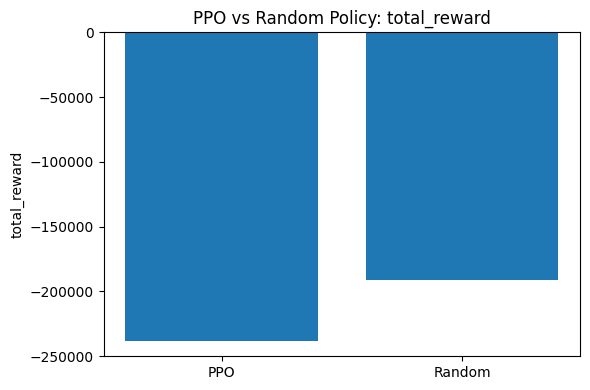

In [34]:
plot_metric_comparison(summary_df, "total_reward")


## Plot Emergency Delays
This plot compares emergency delay counts between PPO and random actions.


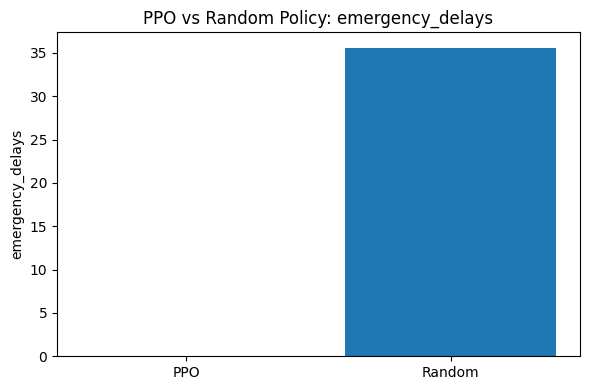

In [35]:
plot_metric_comparison(summary_df, "emergency_delays")


## Plot Successful Discharges
This plot compares successful discharge counts between PPO and random actions.


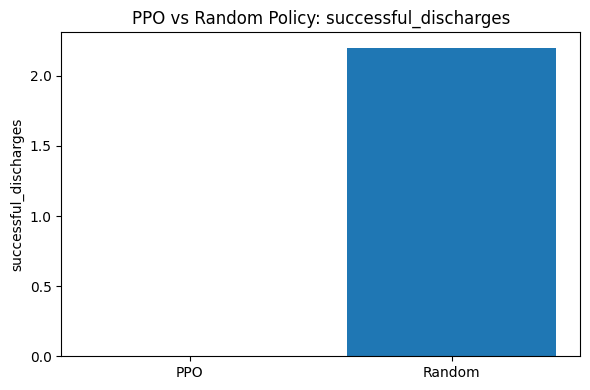

In [36]:
plot_metric_comparison(summary_df, "successful_discharges")


## Plot Unsafe Discharges
This plot compares unsafe discharge counts between PPO and random actions.


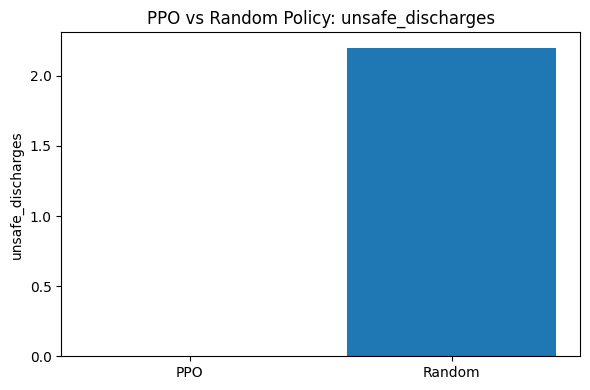

In [37]:
plot_metric_comparison(summary_df, "unsafe_discharges")


## Plot Queue Congestion
This plot compares registration/assessment congestion events.


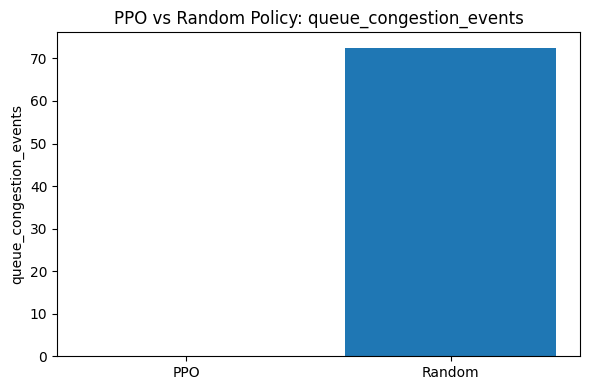

In [38]:
plot_metric_comparison(summary_df, "queue_congestion_events")


## Save Model and CSV Outputs
This saves the PPO model plus PPO, random, and summary result tables.


In [39]:
save_results(model, ppo_results, random_results, summary_df)


Saved PPO model: ppo_hospital_flow_model.zip
Saved PPO results: ppo_evaluation_results.csv
Saved random baseline results: random_policy_results.csv
Saved comparison summary: ppo_vs_random_summary.csv


## Final Printed Summary
PPO is trained on the operational hospital-flow environment and compared against a random policy baseline.
The produced metrics test whether PPO learns better operational decision-making than random actions.


In [40]:
print("PPO training and evaluation complete.")
print(summary_df)


PPO training and evaluation complete.
                    metric  ppo_mean  random_mean       ppo_std    random_std
0             total_reward -238144.1   -190914.61  34112.420957  28143.106254
1         emergency_delays       0.0        35.60      0.000000      5.413434
2        unsafe_discharges       0.0         2.20      0.000000      1.321881
3           icu_admissions       0.0         0.30      0.000000      0.470162
4       general_admissions       0.0         0.15      0.000000      0.366348
5    successful_discharges       0.0         2.20      0.000000      1.321881
6  queue_congestion_events       0.0        72.50      0.000000     98.394212
